In [ ]:
from google.colab import files

uploaded = files.upload()

Saving models_part1 (2).joblib to models_part1 (2) (2).joblib


In [ ]:
import os

print(os.path.exists("/content/models_part1 (2).joblib"))

True


In [ ]:
import joblib

MODEL_PATH = "/content/models_part1 (2).joblib"

trained_pipelines = joblib.load(MODEL_PATH)

print(trained_pipelines.keys())

dict_keys(['Baseline', 'LogisticRegression', 'KNN'])


In [ ]:
#Import thư viện
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

import os

In [ ]:
#Đọc dataset
DATA_PATH = "/content/penguins_size.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (344, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
#Cleaning
numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

categorical_features = [
    "island",
    "sex"
]

target = "species"


# Xử lý giá trị lỗi ở cột sex
df["sex"] = df["sex"].replace(".", np.nan)


# Bỏ dòng mà toàn bộ biến số bị thiếu
df = df.dropna(
    subset=numeric_features,
    how="all"
)


# Bỏ dòng thiếu target
df = df.dropna(
    subset=[target]
)

print("Shape sau cleaning:", df.shape)

Shape sau cleaning: (342, 7)


In [ ]:
#Tạo X và y
X = df[
    numeric_features + categorical_features
]

y = df[target]

In [ ]:
#Encode target
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['Adelie' 'Chinstrap' 'Gentoo']


In [ ]:
#Chia train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (273, 6)
X_test : (69, 6)
y_train: (273,)
y_test : (69,)


In [ ]:
print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Train samples: 273
Test samples : 69

Test class distribution:
0    30
2    25
1    14
Name: count, dtype: int64


In [ ]:
#Tạo thư mục lưu kết quả
EVAL_DIR = "/content/drive/MyDrive/penguin_models/evaluation"

os.makedirs(EVAL_DIR, exist_ok=True)

print("Evaluation directory:", EVAL_DIR)

Evaluation directory: /content/drive/MyDrive/penguin_models/evaluation



MODEL: Baseline

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.43      1.00      0.61        30
   Chinstrap       0.00      0.00      0.00        14
      Gentoo       0.00      0.00      0.00        25

    accuracy                           0.43        69
   macro avg       0.14      0.33      0.20        69
weighted avg       0.19      0.43      0.26        69



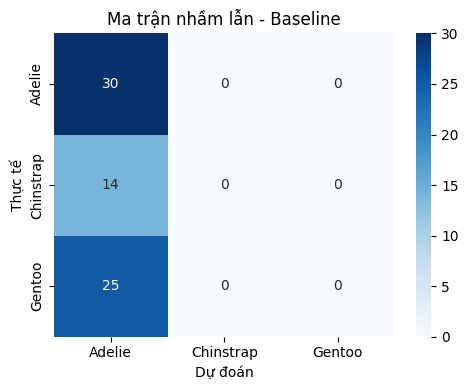

Đã lưu: /content/drive/MyDrive/penguin_models/evaluation/confusion_matrix_Baseline.png

MODEL: LogisticRegression

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



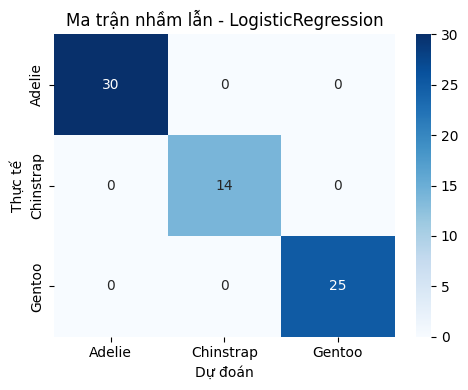

Đã lưu: /content/drive/MyDrive/penguin_models/evaluation/confusion_matrix_LogisticRegression.png

MODEL: KNN

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



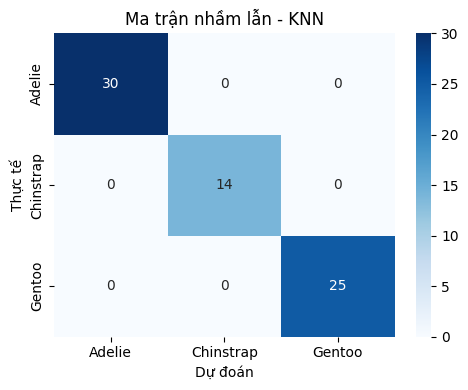

Đã lưu: /content/drive/MyDrive/penguin_models/evaluation/confusion_matrix_KNN.png


In [ ]:
#Evaluate model
eval_rows = []

for name, pipe in trained_pipelines.items():

    print("\n" + "=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    # --------------------------------------------------------
    # Predict test
    # --------------------------------------------------------

    y_pred = pipe.predict(X_test)


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision_macro = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall_macro = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )


    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )


    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    roc_auc = None

    try:

        y_proba = pipe.predict_proba(X_test)

        y_test_bin = label_binarize(
            y_test,
            classes=[0, 1, 2]
        )

        roc_auc = roc_auc_score(
            y_test_bin,
            y_proba,
            average="macro",
            multi_class="ovr"
        )

    except Exception as e:

        print("Không tính được ROC-AUC:", e)


    # --------------------------------------------------------
    # Train accuracy
    # --------------------------------------------------------

    train_pred = pipe.predict(X_train)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )


    # --------------------------------------------------------
    # Train-Test Gap
    # --------------------------------------------------------

    gap_train_test = train_accuracy - accuracy


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    eval_rows.append({

        "model": name,

        "test_accuracy": round(
            accuracy,
            4
        ),

        "train_accuracy": round(
            train_accuracy,
            4
        ),

        "gap_train_test": round(
            gap_train_test,
            4
        ),

        "precision_macro": round(
            precision_macro,
            4
        ),

        "recall_macro": round(
            recall_macro,
            4
        ),

        "f1_macro": round(
            f1_macro,
            4
        ),

        "roc_auc_macro": (
            round(roc_auc, 4)
            if roc_auc is not None
            else None
        )
    })


    # ========================================================
    # Classification report
    # ========================================================

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


    # ========================================================
    # Confusion Matrix
    # ========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(
        f"Ma trận nhầm lẫn - {name}"
    )

    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")

    plt.tight_layout()


    safe_name = name.replace(
        " ",
        "_"
    )

    confusion_path = os.path.join(
        EVAL_DIR,
        f"confusion_matrix_{safe_name}.png"
    )

    plt.savefig(
        confusion_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Đã lưu:",
        confusion_path
    )

In [ ]:
#Tạo bảng so sánh
eval_df = pd.DataFrame(eval_rows)

eval_df = eval_df.sort_values(
    "f1_macro",
    ascending=False
)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(eval_df)


MODEL COMPARISON


,model,test_accuracy,train_accuracy,gap_train_test,precision_macro,recall_macro,f1_macro,roc_auc_macro
1,LogisticRegression,1.0000,1.0000,0.0000,1.0000,1.0000,1.000,1.0
2,KNN,1.0000,1.0000,0.0000,1.0000,1.0000,1.000,1.0
0,Baseline,0.4348,0.4432,0.0084,0.1449,0.3333,0.202,0.5


In [ ]:
#Lưu bảng kết quả
eval_path = os.path.join(
    EVAL_DIR,
    "model_comparison_part1.csv"
)

eval_df.to_csv(
    eval_path,
    index=False
)

print("Đã lưu bảng đánh giá tại:")
print(eval_path)

Đã lưu bảng đánh giá tại:
/content/drive/MyDrive/penguin_models/evaluation/model_comparison_part1.csv


In [ ]:
# ============================================================
# 5. ĐÓNG GÓI MODEL
# ============================================================

import joblib
import json
import sklearn
import pandas as pd
import numpy as np
import datetime
import os

# Thư mục lưu model
MODEL_DIR = "/content/drive/MyDrive/penguin_models/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Chọn model tốt nhất theo F1-macro
# ------------------------------------------------------------

best_model_name = eval_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]

print("Model được chọn:", best_model_name)

# ------------------------------------------------------------
# 2. Lưu model
# ------------------------------------------------------------

model_path = os.path.join(
    MODEL_DIR,
    "model.joblib"
)

joblib.dump(
    best_pipeline,
    model_path,
    compress=3
)

# ------------------------------------------------------------
# 3. Tạo metadata
# ------------------------------------------------------------

metadata = {
    "model_name": best_model_name,
    "model_version": "1.0.0",
    "trained_at": datetime.datetime.now().isoformat(),
    "labels": list(label_encoder.classes_),
    "metrics_test": eval_df.iloc[0].to_dict(),
    "library_versions": {
        "scikit-learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__
    }
}

metadata_path = os.path.join(
    MODEL_DIR,
    "metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        ensure_ascii=False,
        indent=2,
        default=str
    )

# ------------------------------------------------------------
# 4. Kiểm tra file
# ------------------------------------------------------------

print("\nĐÓNG GÓI MODEL THÀNH CÔNG")
print("--------------------------------")

print("Model lưu tại:")
print(model_path)

print(
    "Kích thước:",
    round(os.path.getsize(model_path) / 1024, 2),
    "KB"
)

print("\nMetadata lưu tại:")
print(metadata_path)

Model được chọn: LogisticRegression

ĐÓNG GÓI MODEL THÀNH CÔNG
--------------------------------
Model lưu tại:
/content/drive/MyDrive/penguin_models/models/model.joblib
Kích thước: 2.18 KB

Metadata lưu tại:
/content/drive/MyDrive/penguin_models/models/metadata.json


In [ ]:
import joblib
import pandas as pd

MODEL_PATH = "/content/drive/MyDrive/penguin_models/models/model.joblib"

pipeline = joblib.load(MODEL_PATH)

print("Load model thành công!")
print(type(pipeline))

Load model thành công!
<class 'sklearn.pipeline.Pipeline'>


In [ ]:
sample = pd.DataFrame([{
    "culmen_length_mm": 45.0,
    "culmen_depth_mm": 15.0,
    "flipper_length_mm": 220.0,
    "body_mass_g": 5200.0,
    "island": "Biscoe",
    "sex": "MALE",
}])

pred = pipeline.predict(sample)
proba = pipeline.predict_proba(sample)

print("Prediction:", pred)
print("Probability:", proba)

Prediction: [2]
Probability: [[2.76433362e-04 3.58995661e-05 9.99687667e-01]]


In [ ]:
print(label_encoder.classes_)

In [ ]:
import json

METADATA_PATH = "/content/drive/MyDrive/penguin_models/models/metadata.json"

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

labels = metadata["labels"]

predicted_class = labels[int(pred[0])]

print("Prediction:", predicted_class)
print("Probability:", proba[0])

Prediction: Gentoo
Probability: [2.76433362e-04 3.58995661e-05 9.99687667e-01]


In [ ]:
# ============================================================
# TẠO SCHEMA.JSON
# ============================================================

import json
import os

MODEL_DIR = "/content/drive/MyDrive/penguin_models/models"

schema = {
    "target": "species",
    "features": {
        "culmen_length_mm": {
            "type": "number",
            "required": True
        },
        "culmen_depth_mm": {
            "type": "number",
            "required": True
        },
        "flipper_length_mm": {
            "type": "number",
            "required": True
        },
        "body_mass_g": {
            "type": "number",
            "required": True
        },
        "island": {
            "type": "string",
            "required": True
        },
        "sex": {
            "type": "string",
            "required": True
        }
    }
}

schema_path = os.path.join(
    MODEL_DIR,
    "schema.json"
)

with open(
    schema_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        schema,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Đã tạo schema.json tại:")
print(schema_path)

Đã tạo schema.json tại:
/content/drive/MyDrive/penguin_models/models/schema.json


In [ ]:
print(os.path.exists(schema_path))

In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/penguin_models/models/model.joblib"
)

files.download(
    "/content/drive/MyDrive/penguin_models/models/metadata.json"
)

files.download(
    "/content/drive/MyDrive/penguin_models/models/schema.json"
)

# Download confusion matrix images
files.download(
    "/content/drive/MyDrive/penguin_models/evaluation/confusion_matrix_Baseline.png"
)
files.download(
    "/content/drive/MyDrive/penguin_models/evaluation/confusion_matrix_LogisticRegression.png"
)
files.download(
    "/content/drive/MyDrive/penguin_models/evaluation/confusion_matrix_KNN.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>